# Quick MACE-MH-1 MD Check

This notebook reads one generated `POSCAR_*`, reuses the initial positions and velocities stored in that POSCAR, attaches the local MACE-MH-1 model, and runs a short constant-energy NVE trajectory to check whether the generated initial condition is reasonable.

## Notes

- The notebook is intended for quick validation, not production MD.
- The NVE trajectory starts from the positions and velocities read from the POSCAR.
- By default the notebook uses the local model file `model/mace-mh-1.model`.
- A `tqdm` progress bar is shown during the MD run.
- The final trajectory is animated directly inside the notebook, not only shown as static snapshots.

In [7]:
import json
import os
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "mplconfig_qct_poscar_generator"))

import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np
from IPython.display import HTML, display
from tqdm.auto import tqdm

from ase import units
from ase.io import Trajectory, read
from ase.md.verlet import VelocityVerlet
from ase.visualize.plot import plot_atoms

try:
    import torch
except ImportError as exc:
    raise ImportError("PyTorch is required for MACE. Install it in this environment first.") from exc

try:
    from mace.calculators import mace_mp
except ImportError as exc:
    raise ImportError("mace-torch is required for this notebook. Install it with pip install mace-torch.") from exc

/Users/samuel/Desktop/postdoc_PhLAM/codes/QCT_POSCAR_generator/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
CONFIG = {
    "poscar_glob": "outputs/qct_poscars/POSCAR_*",
    "poscar_index": 0,
    "model_path": "model/mace-mh-1.model",
    "head": "omat_pbe",
    "default_dtype": "float64",
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "dispersion": False,
    "timestep_fs": 1.0,
    "n_steps": 200,
    "log_interval": 5,
    "traj_write_interval": 1,
    "snapshot_stride": 20,
    "animation_stride": 5,
    "animation_interval_ms": 120,
    "initialize_velocities_if_missing": False,
    "fallback_temperature_K": 300.0,
    "output_dir": "outputs/mace_md_check",
    "trajectory_name": "quick_check.traj",
}

print(json.dumps(CONFIG, indent=2))

{
  "poscar_glob": "outputs/qct_poscars/POSCAR_*",
  "poscar_index": 0,
  "model_path": "model/mace-mh-1.model",
  "head": "omat_pbe",
  "default_dtype": "float64",
  "device": "cpu",
  "dispersion": false,
  "timestep_fs": 1.0,
  "n_steps": 200,
  "log_interval": 5,
  "traj_write_interval": 1,
  "snapshot_stride": 20,
  "animation_stride": 5,
  "animation_interval_ms": 120,
  "initialize_velocities_if_missing": false,
  "fallback_temperature_K": 300.0,
  "output_dir": "outputs/mace_md_check",
  "trajectory_name": "quick_check.traj"
}


In [9]:
def choose_poscar(poscar_glob: str, poscar_index: int) -> Path:
    paths = sorted(Path().glob(poscar_glob))
    if not paths:
        raise FileNotFoundError(f"No POSCAR found for pattern: {poscar_glob}")
    if poscar_index < 0 or poscar_index >= len(paths):
        raise IndexError(f"poscar_index={poscar_index} is outside [0, {len(paths) - 1}]")
    return paths[poscar_index]


def build_mace_calculator(config: dict):
    model_path = Path(config["model_path"]).resolve()
    if not model_path.exists():
        raise FileNotFoundError(f"MACE model file not found: {model_path}")
    return mace_mp(
        model=str(model_path),
        head=config["head"],
        device=config["device"],
        default_dtype=config["default_dtype"],
        dispersion=config["dispersion"],
    )


def ensure_velocities(atoms, config: dict) -> None:
    vel = atoms.get_velocities()
    if vel is not None:
        return
    if not config["initialize_velocities_if_missing"]:
        raise ValueError(
            "No velocities were found in the POSCAR. Either regenerate the POSCAR with velocities or set initialize_velocities_if_missing=True."
        )
    from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

    MaxwellBoltzmannDistribution(atoms, temperature_K=config["fallback_temperature_K"])


def summarize_atoms(atoms) -> dict:
    vel = atoms.get_velocities()
    return {
        "natoms": len(atoms),
        "formula": atoms.get_chemical_formula(),
        "cell_lengths_A": atoms.cell.lengths().tolist(),
        "pbc": atoms.pbc.tolist(),
        "has_velocities": vel is not None,
        "max_velocity_A_fs": None if vel is None else float(np.abs(vel).max()),
    }


def plot_structure_views(atoms, title: str = "Initial structure"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    rotations = ["0x,0y,0z", "90x,0y,0z", "0x,90y,0z"]
    labels = ["Top view", "Side view xz", "Side view yz"]
    for ax, rot, label in zip(axes, rotations, labels):
        plot_atoms(atoms, ax, rotation=rot, radii=0.5)
        ax.set_title(label)
        ax.set_axis_off()
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def run_nve(atoms, config: dict):
    output_dir = Path(config["output_dir"])
    output_dir.mkdir(parents=True, exist_ok=True)
    traj_path = output_dir / config["trajectory_name"]
    if traj_path.exists():
        traj_path.unlink()

    dyn = VelocityVerlet(atoms, timestep=config["timestep_fs"] * units.fs)
    trajectory = Trajectory(str(traj_path), "w", atoms)

    history = {
        "step": [],
        "time_fs": [],
        "epot_eV": [],
        "ekin_eV": [],
        "etot_eV": [],
        "temperature_K": [],
    }

    def log_step(write_frame: bool = True):
        step = dyn.nsteps
        epot = atoms.get_potential_energy()
        ekin = atoms.get_kinetic_energy()
        temp = atoms.get_temperature()
        history["step"].append(step)
        history["time_fs"].append(step * config["timestep_fs"])
        history["epot_eV"].append(epot)
        history["ekin_eV"].append(ekin)
        history["etot_eV"].append(epot + ekin)
        history["temperature_K"].append(temp)
        if write_frame:
            trajectory.write(atoms)

    log_step(write_frame=True)
    for _ in tqdm(range(config["n_steps"]), desc="NVE steps"):
        dyn.run(1)
        write_frame = (dyn.nsteps % config["traj_write_interval"] == 0)
        if write_frame or (dyn.nsteps % config["log_interval"] == 0):
            log_step(write_frame=write_frame)

    trajectory.close()
    return history, traj_path


def plot_md_diagnostics(history: dict):
    t = np.array(history["time_fs"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(t, history["epot_eV"], label="Epot")
    axes[0].plot(t, history["ekin_eV"], label="Ekin")
    axes[0].plot(t, history["etot_eV"], label="Etot")
    axes[0].set_xlabel("Time (fs)")
    axes[0].set_ylabel("Energy (eV)")
    axes[0].legend()
    axes[0].set_title("Energy conservation check")

    axes[1].plot(t, history["temperature_K"], color="tab:red")
    axes[1].set_xlabel("Time (fs)")
    axes[1].set_ylabel("Temperature (K)")
    axes[1].set_title("Instantaneous temperature")

    fig.tight_layout()
    return fig


def plot_trajectory_snapshots(traj_path: Path, stride: int = 20, max_frames: int = 6):
    frames = read(traj_path, index=":")
    if not isinstance(frames, list):
        frames = [frames]
    sampled = frames[::stride][:max_frames]
    if not sampled:
        raise ValueError("No trajectory frames available for plotting.")

    fig, axes = plt.subplots(len(sampled), 2, figsize=(10, 3 * len(sampled)))
    if len(sampled) == 1:
        axes = np.array([axes])

    for i, atoms_i in enumerate(sampled):
        plot_atoms(atoms_i, axes[i, 0], rotation="0x,0y,0z", radii=0.5)
        plot_atoms(atoms_i, axes[i, 1], rotation="90x,0y,0z", radii=0.5)
        axes[i, 0].set_axis_off()
        axes[i, 1].set_axis_off()
        axes[i, 0].set_title(f"Frame {i * stride}: top")
        axes[i, 1].set_title(f"Frame {i * stride}: side")

    fig.tight_layout()
    return fig


def animate_trajectory(traj_path: Path, stride: int = 5, interval_ms: int = 120):
    frames = read(traj_path, index=":")
    if not isinstance(frames, list):
        frames = [frames]
    frames = frames[::stride]
    if not frames:
        raise ValueError("No trajectory frames available for animation.")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    def draw_frame(i: int):
        for ax in axes:
            ax.clear()
            ax.set_axis_off()
        plot_atoms(frames[i], axes[0], rotation="0x,0y,0z", radii=0.5)
        plot_atoms(frames[i], axes[1], rotation="90x,0y,0z", radii=0.5)
        axes[0].set_title(f"Frame {i * stride}: top")
        axes[1].set_title(f"Frame {i * stride}: side")
        return axes

    ani = animation.FuncAnimation(fig, draw_frame, frames=len(frames), interval=interval_ms, blit=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

In [10]:
poscar_path = choose_poscar(CONFIG["poscar_glob"], CONFIG["poscar_index"])
atoms = read(poscar_path, format="vasp")
ensure_velocities(atoms, CONFIG)
atoms.calc = build_mace_calculator(CONFIG)

summary = summarize_atoms(atoms)
print(f"Selected POSCAR: {poscar_path}")
print("Initial positions and velocities were read directly from this POSCAR.")
print(json.dumps(summary, indent=2))
print(f"Initial potential energy: {atoms.get_potential_energy():.6f} eV")
print(f"Initial max |force|: {np.abs(atoms.get_forces()).max():.6f} eV/A")

/Users/samuel/Desktop/postdoc_PhLAM/codes/QCT_POSCAR_generator/.venv/lib/python3.14/site-packages/mace/calculators/mace.py:199: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.
Selected POSCAR: outputs/qct_poscars/POSCAR_000
Initial positions and velocities were read directly from this POSCAR.
{
  "natoms": 99,
  "formula": "C96O2S",
  "cell_lengths_A": [
    9.86546421,
    9.865464209399391,
    26.72727394
  ],
  "pbc": [
    true,
    true,
    true
  ],
  "has_velocities": true,
  "max_velocity_A_fs": 0.25303524878235334
}
Initial potential energy: -897.664247 eV
Initial max |force|: 6.813165 eV/A


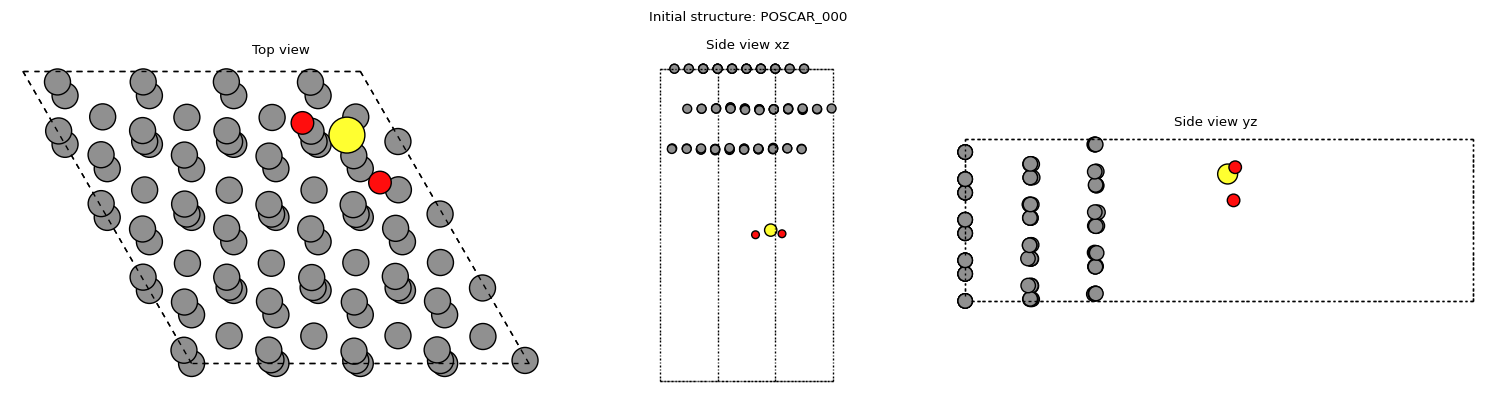

In [11]:
plot_structure_views(atoms, title=f"Initial structure: {poscar_path.name}")
plt.show()

In [12]:
history, traj_path = run_nve(atoms, CONFIG)
print(f"Trajectory written to: {traj_path}")
print(f"Final total energy: {history['etot_eV'][-1]:.6f} eV")
print(f"Initial total energy: {history['etot_eV'][0]:.6f} eV")
print(f"Energy drift: {history['etot_eV'][-1] - history['etot_eV'][0]:.6e} eV")

NVE steps: 100%|██████████| 200/200 [01:45<00:00,  1.89it/s]

Trajectory written to: outputs/mace_md_check/quick_check.traj
Final total energy: -895.450455 eV
Initial total energy: -895.433375 eV
Energy drift: -1.708049e-02 eV


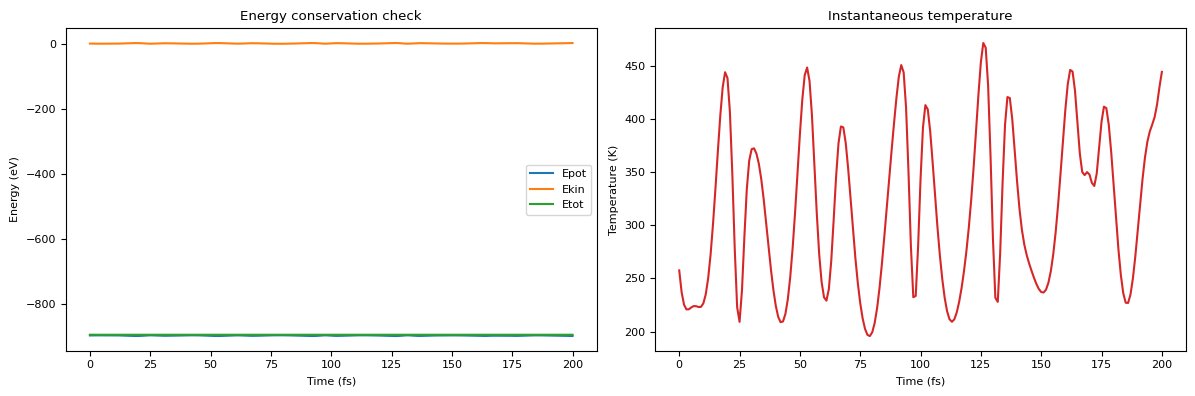

In [13]:
plot_md_diagnostics(history)
plt.show()

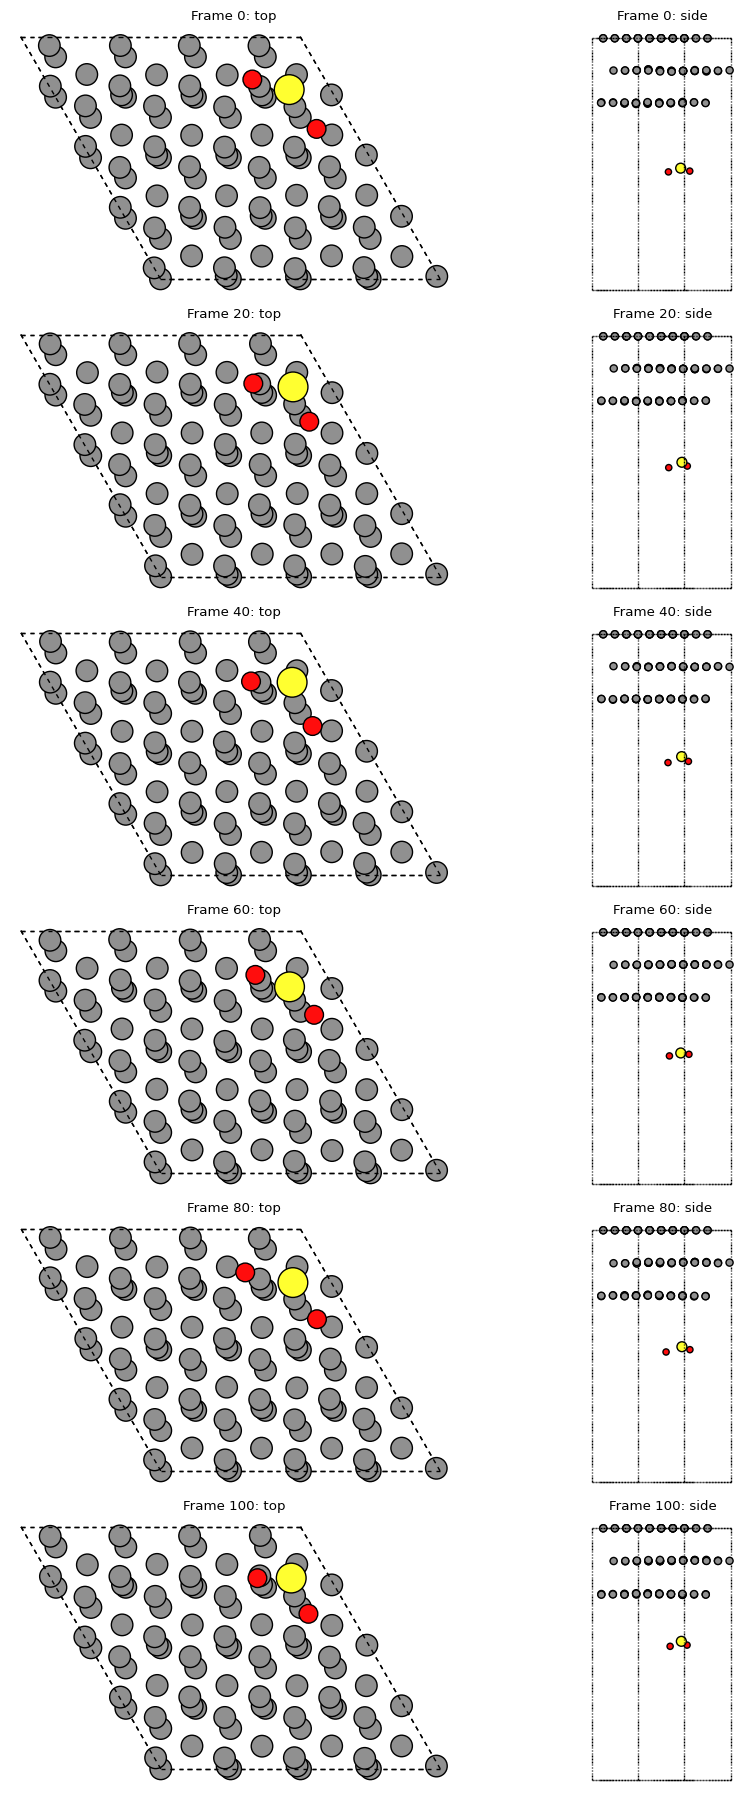

In [14]:
plot_trajectory_snapshots(traj_path, stride=CONFIG["snapshot_stride"])
plt.show()

In [15]:
display(animate_trajectory(traj_path, stride=CONFIG["animation_stride"], interval_ms=CONFIG["animation_interval_ms"]))

## Interpretation

- Check the initial structure views for obvious overlaps or unrealistic molecule placement.
- Check whether the initial forces are excessively large.
- In short NVE, watch whether the structure immediately explodes, desorbs unphysically, or shows extreme energy drift.
- Use the animation to confirm that the incoming molecule moves with the expected initial velocity.
- If a configuration is suspicious, change `poscar_index` and rerun the notebook on another generated POSCAR.